# 03 — CNN-LSTM Dual Branch
### Dual-branch CNN-LSTM — Baseline 3
> Vibration processed by CNN. Electrical features processed by Dense. LSTM reads degradation progression.
> Run 00_Data_Preparation.ipynb first.

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

✅ Device: cpu


In [2]:
with open('prepared_data.pkl','rb') as f: d = pickle.load(f)
with open('encoder.pkl','rb') as f: encoder = pickle.load(f)

X_train = torch.FloatTensor(d['X_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_test_seq']).to(DEVICE)
y_train = torch.LongTensor(d['y_train_seq']).to(DEVICE)
y_test  = torch.LongTensor(d['y_test_seq']).to(DEVICE)

NUM_CLASSES   = d['num_classes']
NUM_FEATURES  = d['num_features']
TIME_STEPS    = d['TIME_STEPS']
NUM_VIB       = 60
NUM_ELEC      = 6

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
print(f'✅ Data loaded.  VIB={NUM_VIB}  ELEC={NUM_ELEC}  Total={NUM_FEATURES}')

✅ Data loaded.  VIB=60  ELEC=6  Total=66


#### Dual-Branch CNN-LSTM Architecture
> Branch 1: Conv1D slides across 60 vibration bands detecting local frequency spikes
> Branch 2: Dense processes 6 electrical features independently
> Merged output fed to LSTM for temporal progression learning

In [3]:
class DualBranchCNNLSTM(nn.Module):
    def __init__(self, num_vib, num_elec, time_steps, num_classes, dropout=0.2):
        super().__init__()
        self.num_vib   = num_vib
        self.num_elec  = num_elec
        self.time_steps = time_steps

        # ── VIBRATION BRANCH: CNN ─────────────────────────────────────
        # Input per timestep: (batch, num_vib, 1)
        # Detects local frequency patterns — e.g. 70-80Hz spike = Blade Blunt
        self.vib_conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout)
        )
        vib_out_size = 32 * (num_vib // 2)

        # ── ELECTRICAL BRANCH: Dense ──────────────────────────────────
        # Input per timestep: (batch, num_elec)
        self.elec_fc = nn.Sequential(
            nn.Linear(num_elec, 16),
            nn.BatchNorm1d(16),
            nn.ReLU()
        )

        # ── LSTM: reads merged representation across time_steps ───────
        merged_size = vib_out_size + 16
        self.lstm   = nn.LSTM(merged_size, 64, 2, batch_first=True, dropout=dropout)
        self.drop   = nn.Dropout(dropout)

        # ── CLASSIFIER HEAD ───────────────────────────────────────────
        self.fc1    = nn.Linear(64, 32)
        self.relu   = nn.ReLU()
        self.fc2    = nn.Linear(32, num_classes)

    def forward(self, x):
        # x shape: (batch, time_steps, 66)
        batch = x.size(0)
        vib_in  = x[:, :, :self.num_vib]   # (batch, time_steps, 60)
        elec_in = x[:, :, self.num_vib:]   # (batch, time_steps, 6)

        # Process each timestep through CNN
        vib_feats = []
        for t in range(self.time_steps):
            vt = vib_in[:, t, :].unsqueeze(1)          # (batch, 1, 60)
            vt = self.vib_conv(vt)                      # (batch, 32, 30)
            vib_feats.append(vt.view(batch, -1))        # (batch, 960)
        vib_seq = torch.stack(vib_feats, dim=1)         # (batch, time_steps, 960)

        # Process each timestep through Dense
        elec_feats = []
        for t in range(self.time_steps):
            et = elec_in[:, t, :]                       # (batch, 6)
            elec_feats.append(self.elec_fc(et))         # (batch, 16)
        elec_seq = torch.stack(elec_feats, dim=1)       # (batch, time_steps, 16)

        # Merge and feed to LSTM
        merged = torch.cat([vib_seq, elec_seq], dim=2)  # (batch, time_steps, 976)
        out, _ = self.lstm(merged)
        out    = self.drop(out[:, -1, :])               # last timestep
        out    = self.relu(self.fc1(out))
        return self.fc2(out)

model = DualBranchCNNLSTM(NUM_VIB, NUM_ELEC, TIME_STEPS, NUM_CLASSES).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 309,045


#### Train

Epoch  10 | Train: 0.3885 | Val: 0.3933
Epoch  20 | Train: 0.3807 | Val: 0.3974
Early stopping at epoch 22


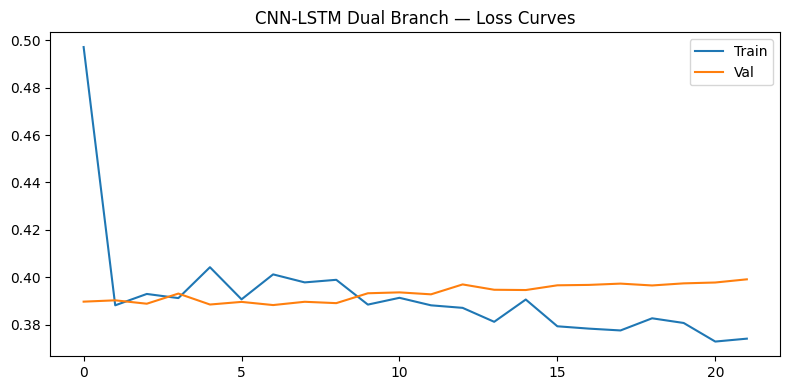

In [ ]:
EPOCHS    = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 15
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test), y_test).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_cnn_lstm.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('CNN-LSTM Dual Branch — Loss Curves')
plt.legend()
plt.tight_layout()
plt.savefig('cnn_lstm_loss.png', dpi=150)
plt.show()

#### Evaluate

CNN-LSTM DUAL BRANCH RESULTS
Accuracy : 92.04%
F1 Score : 0.8823
RMSE     : 0.5439
MAE      : 0.1386

                    precision    recall  f1-score   support

       Blade Blunt       0.00      0.00      0.00        21
           Healthy       0.92      1.00      0.96       983
High Foot Pressure       0.00      0.00      0.00        22
Skip Stitches/Slip       0.00      0.00      0.00        21
          Waveness       0.00      0.00      0.00        21

          accuracy                           0.92      1068
         macro avg       0.18      0.20      0.19      1068
      weighted avg       0.85      0.92      0.88      1068



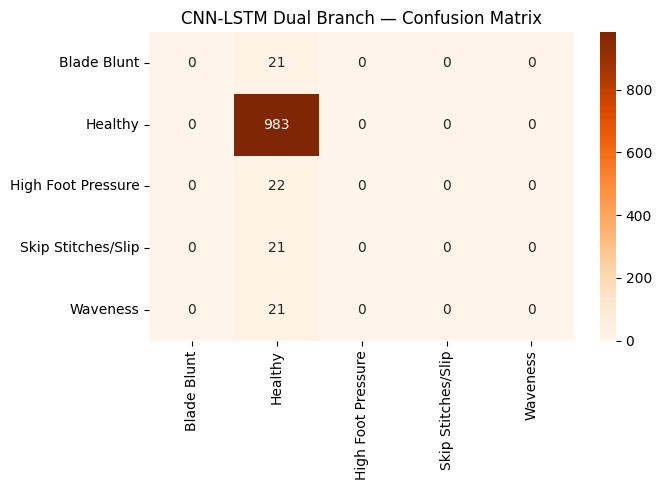

✅ Results saved to cnn_lstm_results.pkl


In [5]:
model.load_state_dict(torch.load('best_cnn_lstm.pt'))
model.eval()
with torch.no_grad():
    y_pred = np.argmax(torch.softmax(model(X_test),dim=1).cpu().numpy(), axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('CNN-LSTM DUAL BRANCH RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('CNN-LSTM Dual Branch — Confusion Matrix')
plt.tight_layout()
plt.savefig('cnn_lstm_confusion.png', dpi=150)
plt.show()

cnn_lstm_results = {'model':'CNN-LSTM','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('cnn_lstm_results.pkl','wb') as f: pickle.dump(cnn_lstm_results, f)
print('✅ Results saved to cnn_lstm_results.pkl')